# HW3 - PyTorch Tutorial

In [1]:
import torch # get PyTorch
import numpy as np 

1. Tensors:
Tensors are a specialized form of data structures quite similar to arrays and matrices, and are used to encode the inputs and outputs of a model and its parameters. In retrospect, its similar to NumPy's ndarrays but it can run on GPUs to accelerate computing.

Tensor Initialization: A tensor may be initialized in quite a few ways:
A. Directly from data

In [2]:
data = [[1, 2], [3, 4]]
x_data = torch.tensor(data)

B. From a NumPy array

In [3]:
np_array = np.array(data)
x_np = torch.from_numpy(np_array)

C. From another Tensor: Retains the properties of the original tensor unless explicitly overridden.

In [4]:
x_ones = torch.ones_like(x_data) # retains the properties of x_data
print(f"Ones Tensor: \n {x_ones} \n")

x_rand = torch.rand_like(x_data, dtype=torch.float) # overrides the datatype of x_data
print(f"Random Tensor: \n {x_rand} \n")

Ones Tensor: 
 tensor([[1, 1],
        [1, 1]]) 

Random Tensor: 
 tensor([[0.3370, 0.7913],
        [0.4887, 0.1192]]) 



D. With random or constant values: 
Define 'shape' to be a tuple of tensor dimensions.

In [ ]:
shape = (2, 3,) # 2 rows and 3 columns
rand_tensor = torch.rand(shape)
ones_tensor = 5.16*torch.ones(shape) # Can be multiplied with any constant 'k'
zeros_tensor = torch.zeros(shape)

print(f"Random Tensor: \n {rand_tensor} \n")
print(f"Ones Tensor: \n {ones_tensor} \n")
print(f"Zeros Tensor: \n {zeros_tensor}")

Random Tensor: 
 tensor([[0.4985, 0.1906, 0.1571],
        [0.0641, 0.0250, 0.5818]]) 

Ones Tensor: 
 tensor([[5.1600, 5.1600, 5.1600],
        [5.1600, 5.1600, 5.1600]]) 

Zeros Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]])


Tensor Attributes:
Tensor attributes describe the Tensor's shape, datatype and device of storage.

In [ ]:
tensor = torch.rand(3, 4)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}") # I think it is CPU by default

Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


Tensor Operations:
There exist over 100 tensor operations like transposing, indexing, slicing, math operations, linear algebra, random sampling and so on. Here, we can use a GPU to accelerate Tensor Operations if it is available. 

In [10]:
# Select the appropriate hardware target
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
tensor = tensor.to(device)
print(f"Device tensor is stored on: {tensor.device}")

Device tensor is stored on: mps:0


This just shows that I am not using CUDA(Nvidia's GPU interface) but I'm using Apple's MPS(Metal Performance Shaders).

Some operations include numpy-like indexing, slicing and concatenation

In [ ]:
tensor = 3*torch.ones(4, 4) # changed it up
tensor[:,1] = 0
print(tensor)
t1 = torch.cat([tensor, tensor, tensor], dim=1)
print("Concatenated Tensor:\n",t1)

tensor([[3., 0., 3., 3.],
        [3., 0., 3., 3.],
        [3., 0., 3., 3.],
        [3., 0., 3., 3.]])
Concatenated Tensor:
 tensor([[3., 0., 3., 3., 3., 0., 3., 3., 3., 0., 3., 3.],
        [3., 0., 3., 3., 3., 0., 3., 3., 3., 0., 3., 3.],
        [3., 0., 3., 3., 3., 0., 3., 3., 3., 0., 3., 3.],
        [3., 0., 3., 3., 3., 0., 3., 3., 3., 0., 3., 3.]])


Tensor Multiplication: This is a crucial step as we will see later. Also included is the matrix multiplication between 2 tensors

In [19]:
print(f"tensor * tensor \n {tensor * tensor}")
print(f"tensor @ tensor.T \n {tensor @ tensor.T}")

tensor * tensor 
 tensor([[9., 0., 9., 9.],
        [9., 0., 9., 9.],
        [9., 0., 9., 9.],
        [9., 0., 9., 9.]])
tensor @ tensor.T 
 tensor([[27., 27., 27., 27.],
        [27., 27., 27., 27.],
        [27., 27., 27., 27.],
        [27., 27., 27., 27.]])


Some operations that have a '_' suffix are in-place operations, which just means that the original tensor will change

In [20]:
print(tensor, "\n")
tensor.add_(5)
print(tensor)

tensor([[3., 0., 3., 3.],
        [3., 0., 3., 3.],
        [3., 0., 3., 3.],
        [3., 0., 3., 3.]]) 

tensor([[8., 5., 8., 8.],
        [8., 5., 8., 8.],
        [8., 5., 8., 8.],
        [8., 5., 8., 8.]])


The Bridging with NumPy:
Tensors in the CPU and NumPy arrays can share memory locations and therefore, changing one affects the other.

In [22]:
# 1. Tensor to NumPy array
print("Tensor to NumPy array")
t = 7*torch.ones(5)
print(f"t: {t}")
n = t.numpy()
print(f"n: {n}")
t.add_(1) # change in one
print(f"t: {t}")
print(f"n: {n}")
# 2. NumPy array to Tensor
print("NumPy array to Tensor")
n = 9*np.ones(5)
t = torch.from_numpy(n)
np.add(n, 1, out=n)
print(f"t: {t}")
print(f"n: {n}")


Tensor to NumPy array
t: tensor([7., 7., 7., 7., 7.])
n: [7. 7. 7. 7. 7.]
t: tensor([8., 8., 8., 8., 8.])
n: [8. 8. 8. 8. 8.]
NumPy array to Tensor
t: tensor([10., 10., 10., 10., 10.], dtype=torch.float64)
n: [10. 10. 10. 10. 10.]


2. An Introduction to "torch.autograd"
torch.autograd is PyTorch's automatic differentiation engine which is used in Neural Network training. The functions in Neural Nets are determined by parameters(weights and biases) and stored in PyTorch on tensors.

In [44]:
import torch
from torchvision.models import resnet18, ResNet18_Weights
model = resnet18(weights=ResNet18_Weights.DEFAULT)
data = torch.rand(1, 3, 64, 64)
labels = torch.rand(1, 1000)

Now, lets run the input data through each of its layers to form a prediction(forward pass) and calculate the error(loss). Then we use an optimizer(Use Stochastic Gradient Descent with a learning rate of 0.01 and momentum of 0.9-the momentum accelerates convergence by adding a "memory" of past gradient updates) and adjust each parameter by its gradient.

In [ ]:
prediction = model(data) # forward pass
loss = (prediction - labels).sum()
loss.backward() # backprop
optim = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)
optim.step() #gradient descent

An example code:

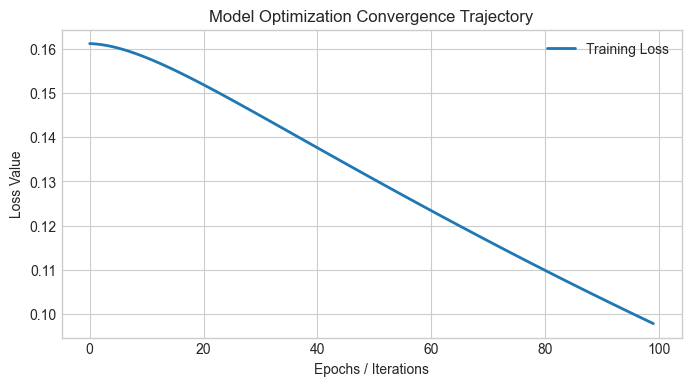

In [ ]:
optim = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)
loss_history = []
for epoch in range(100): 
    optim.zero_grad()
    prediction = model(data) # forward prop
    loss = torch.mean((prediction - labels) ** 2) # MSE loss
    loss.backward() # backprop
    optim.step() # Update weights
    loss_history.append(loss.item())
plt.style.use('seaborn-v0_8-whitegrid') # Clean visual anchor style
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='#1f77b4', linewidth=2, label='Training Loss')
plt.title('Model Optimization Convergence Trajectory')
plt.xlabel('Epochs / Iterations')
plt.ylabel('Loss Value')
plt.legend()
plt.show()

Neural Networks:
Neural Networks are a collection of nested functions loosely based on a human neuron. They can be constructed using the torch.nn package. A typical training a NN consists of the following:
1. Define the NN with some parameters(weights)
2. Iterate over a dataset of inputs
3. Process the inputs throught the network
4. Calculate Loss
5. Propagate gradients backwards
6. Update weights

1. Define the network

In [53]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):

    def __init__(self):
        super().__init__()
        # 1 input image channel, 6 output channels, 5x5 square convolution
        # kernel
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        # an affine operation: y = Wx + b
        self.fc1 = nn.Linear(16 * 5 * 5, 120)  # 5*5 from image dimension
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, input):
        # Convolution layer C1: 1 input image channel, 6 output channels,
        # 5x5 square convolution, it uses RELU activation function, and
        # outputs a Tensor with size (N, 6, 28, 28), where N is the size of the batch
        c1 = F.relu(self.conv1(input))
        # Subsampling layer S2: 2x2 grid, purely functional,
        # this layer does not have any parameter, and outputs a (N, 6, 14, 14) Tensor
        s2 = F.max_pool2d(c1, (2, 2))
        # Convolution layer C3: 6 input channels, 16 output channels,
        # 5x5 square convolution, it uses RELU activation function, and
        # outputs a (N, 16, 10, 10) Tensor
        c3 = F.relu(self.conv2(s2))
        # Subsampling layer S4: 2x2 grid, purely functional,
        # this layer does not have any parameter, and outputs a (N, 16, 5, 5) Tensor
        s4 = F.max_pool2d(c3, 2)
        # Flatten operation: purely functional, outputs a (N, 400) Tensor
        s4 = torch.flatten(s4, 1)
        # Fully connected layer F5: (N, 400) Tensor input,
        # and outputs a (N, 120) Tensor, it uses RELU activation function
        f5 = F.relu(self.fc1(s4))
        # Fully connected layer F6: (N, 120) Tensor input,
        # and outputs a (N, 84) Tensor, it uses RELU activation function
        f6 = F.relu(self.fc2(f5))
        # Fully connected layer OUTPUT: (N, 84) Tensor input, and
        # outputs a (N, 10) Tensor
        output = self.fc3(f6)
        return output


net = Net()
print(net)

Net(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


The forward prop and backprop are automatically defined by autograd. The learnable parameters are returned by net.parameters()

In [54]:
params = list(net.parameters())
print(len(params))
print(params[0].size())

10
torch.Size([6, 1, 5, 5])


Lets try a random input

In [56]:
input = torch.randn(1, 1, 32, 32)
out = net(input)
print(out)

tensor([[ 0.0229, -0.0415,  0.1028,  0.0965,  0.0170, -0.0649, -0.1186,  0.0389,
         -0.1182, -0.0355]], grad_fn=<AddmmBackward0>)


2. The Loss Function:
The Loss function computes the error of the output from the target. There are a lot of loss functions, we use nn.MSELoss which computes the Mean Squared error between the output and target.

In [62]:
output = net(input)
target = torch.randn(10)  
target = target.view(1, -1)  # making it the same shape
criterion = nn.MSELoss()
loss = criterion(output, target)
print(loss)

tensor(1.0955, grad_fn=<MseLossBackward0>)


3. Backpropagation:
We compute loss.backward() to backpropagate the error across all layers(the entire net is differentiated w.r.t the weights). Remember to clear the gradients, else they will accumulate

In [63]:
net.zero_grad()     # zeroes the gradient buffers of all parameters

print('conv1.bias.grad before backward')
print(net.conv1.bias.grad)

loss.backward()

print('conv1.bias.grad after backward')
print(net.conv1.bias.grad)

conv1.bias.grad before backward
None
conv1.bias.grad after backward
tensor([ 0.0127, -0.0002,  0.0020,  0.0193, -0.0011,  0.0052])


4. Update the Weights
In SGD, the criterion is weight=weight-learning_rate*gradient
In the code above, optim.step() does this.

Training a Classifier
We use the CIFAR10 training and test datasets using torchvision.

In [64]:
import torch
import torchvision
from torchvision.transforms import v2
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170498071/170498071 [29:26<00:00, 96492.99it/s] 


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


Define the NN

In [78]:
import torch.nn as nn
import torch.nn.functional as F
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

Define a Loss Function and Optimizer

In [79]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

Train the network

In [80]:
for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 2.192
[1,  4000] loss: 1.840
[1,  6000] loss: 1.701
[1,  8000] loss: 1.612
[1, 10000] loss: 1.538
[1, 12000] loss: 1.505
[2,  2000] loss: 1.430
[2,  4000] loss: 1.374
[2,  6000] loss: 1.355
[2,  8000] loss: 1.336
[2, 10000] loss: 1.317
[2, 12000] loss: 1.308
Finished Training


Test the Model on the test dataset

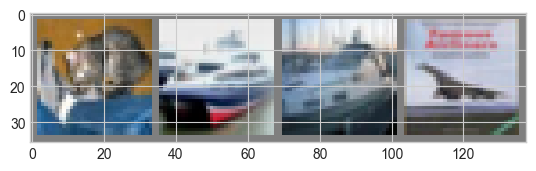

GroundTruth:  cat   ship  ship  plane
Predicted:  cat   car   ship  plane


In [81]:
PATH = './cifar_net.pt'
torch.save(net.state_dict(), PATH)
dataiter = iter(testloader)
images, labels = next(dataiter)
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()
# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))
net = Net()
net.load_state_dict(torch.load(PATH, weights_only=True))
outputs = net(images)
_, predicted = torch.max(outputs, 1)
print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'for j in range(4)))

Let's see how the network did on the whole dataset

In [82]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 53 %


Maybe look at it classwise so that we know which classes did well and which didn't.

In [83]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 69.7 %
Accuracy for class: car   is 75.9 %
Accuracy for class: bird  is 41.4 %
Accuracy for class: cat   is 39.6 %
Accuracy for class: deer  is 61.4 %
Accuracy for class: dog   is 29.5 %
Accuracy for class: frog  is 51.0 %
Accuracy for class: horse is 47.2 %
Accuracy for class: ship  is 65.0 %
Accuracy for class: truck is 54.5 %


It did the best on car and then on plane, deer and ship which were relatively okay. Not too bad for such a small network!

That concludes the Tutorial!